In [88]:
# ENSO QUICK-LOOK REPLACEMENT FOR MY ncl SCRIPT


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.fft import fft, fftfreq
from scipy.signal import correlate
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.colors as mcolors


import pandas as pd

import enso_quick_look_utils as enso_ql

import importlib


** 1. Grabbing Case Data **
  - Grabbing  ERA5  data for TS
1979 2021


/glade/derecho/scratch/rneale/tmp/ipykernel_58237/3435292.py:171: RuntimeWarning: divide by zero encountered in divide
  periods = 1 / (12.*xf)  # now safe, xf[0] excluded
/glade/derecho/scratch/rneale/tmp/ipykernel_58237/3435292.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on the right for colorbar


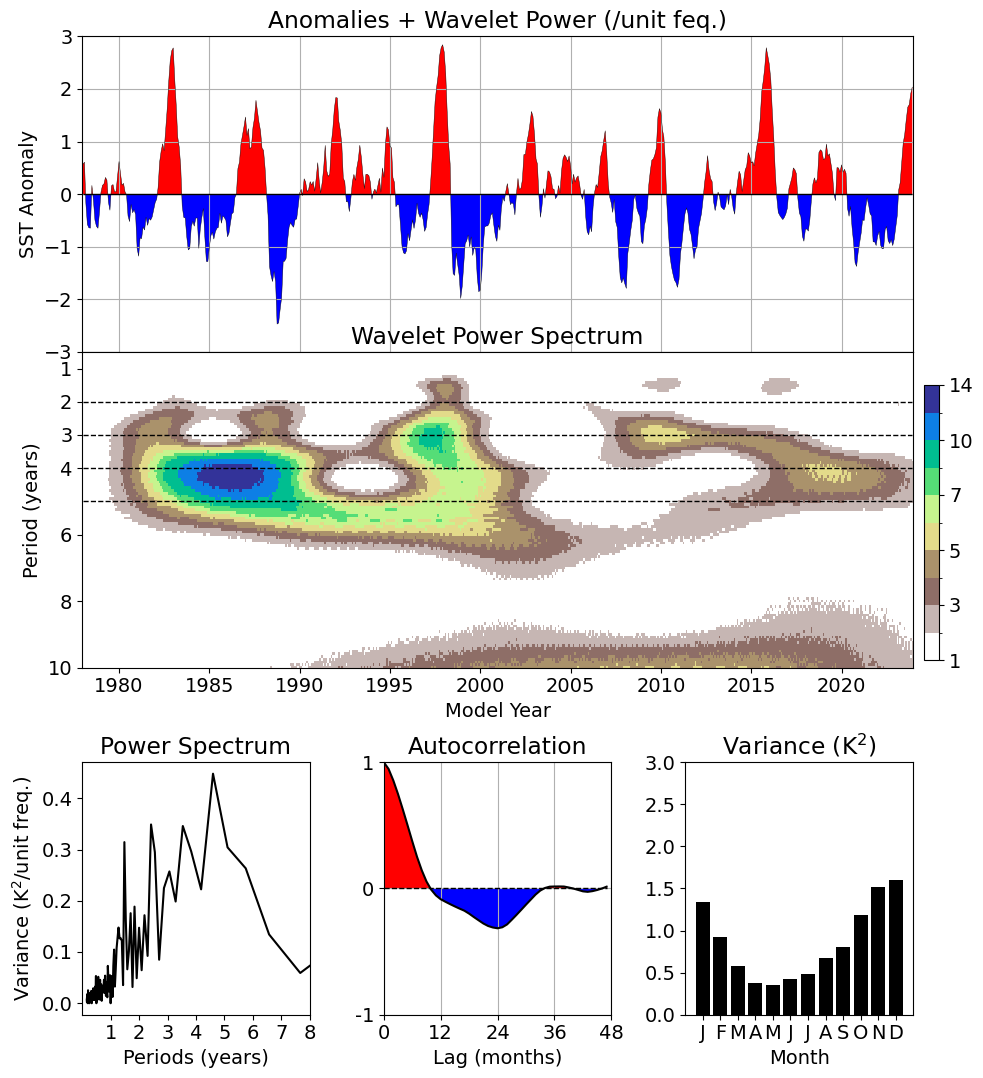

In [58]:
importlib.reload(enso_ql)

# Simulated Niño3.4 data if you don't have it
#np.random.seed(0)
#n_months = 12 * 50  # 50 years of monthly data
#nino34 = np.random.normal(0, 1, n_months) + np.sin(np.linspace(0, 30 * 2*np.pi, n_months))

cnames = 'ERA5'

# 1. Grab data for x-axis and y-axis variable (obs. or model)

print('')
print('** 1. Grabbing Case Data **')

# Some manipulation becasue of obs. could be different types ('cases').

year_start = 1979
year_stop = 2021

da_sst = enso_ql.get_dataset('ERA5','OBS','TS',year_start,year_stop,True,False,False)
#display(da_sst)

# 2. Time info check

#print('')
#print('** 2. Checking and Trimming Time Dimensions')
#da_x, da_y = mypy.dataset_ts_trim(da_x, da_y, yr0, yr1, var_x, var_y, get_months)

# Calculate nino3.4 and VAR timeseries.
#print('')
#print('** 3. Calculating Nino Anomalies')

nino_reg = 'nino34'
nino_ts = enso_ql.nino_anom_ts(da_sst,nino_reg)

time = da_sst.time
dates = pd.to_datetime(time.values)
ntime = len(time)
#mdates = dates.date2num(dates)

#n_months = 12*(year_stop-year_start+1)
#time = pd.date_range("1980-01", periods=n_months, freq="MS")



''' SETUP GRAPHICS '''
# Setup portrait layout: top 1/3, middle 1/3, bottom split in 3
fig = plt.figure(figsize=(10.5, 11))  # US letter portrait
plt.rcParams.update({'font.size': 14})  # sets font size globally

gs = gridspec.GridSpec(nrows=4, ncols=3, height_ratios=[1, 1, 0.3, 0.8],hspace=0.3)

# Top 2 rows — full width (colspan=3)
ax1 = fig.add_subplot(gs[0, :])  # Top row
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)  # Second row, shared x-axis

gs.update(hspace=0.0)

ax3 = fig.add_subplot(gs[3, 0])
ax4 = fig.add_subplot(gs[3, 1])
ax5 = fig.add_subplot(gs[3, 2])



print(year_start,year_stop)









''' PLOT TIME SERIES '''

# Plot 1: Time series
p1 = ax1.plot(time, nino_ts, color='black', linewidth=0.3)

ax1.set_title("Anomalies + Wavelet Power (/unit feq.)")
ax1.set_ylabel("SST Anomaly")
ax1.grid(True)
ax1.fill_between(time,nino_ts,0, where=nino_ts > 0.,  facecolor='red', interpolate=True)
ax1.fill_between(time,nino_ts,0, where=nino_ts < 0.,  facecolor='blue', interpolate=True)
ax1.hlines(0., min(time), max(time), color='black',linestyle="dashed",lw=1,ls='-')
ax1.set_ylim([-3.,3.])









''' PLOT WAVELET '''

# Plot 2: Wavelet spectrum
wavelet = 'cmor1.5-1.0'  # Complex Morlet
scales = np.arange(1, 512)
coeffs, freqs = pywt.cwt(nino_ts, scales, wavelet, sampling_period=1)
periods = 1./(12.*freqs)
power = np.abs(coeffs)**2

levels = [1,2,3,4,5,6,7,8,10,12,14]

cmap = plt.get_cmap('terrain_r', len(levels)-1)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)


p2 = ax2.pcolormesh(time, periods, power, shading='nearest', cmap=cmap,norm=norm)

for ii in [2,3,4,5]:
    ax2.hlines(ii, colors='black', xmin=min(time),xmax=max(time),linestyles='--',lw=1)



ax2.set_title("Wavelet Power Spectrum")
ax2.set_ylabel("Period (years)")
ax2.set_xlabel("Model Year")
ax2.set_ylim(0.5, 10)
yperiods = [1,2,3,4,6,8,10]

ax2.set_yticks(yperiods)
ax2.set_yticklabels(yperiods)
ax2.invert_yaxis()


#xticks = np.arange(0, ntime, 12)
#ax2.set_xticks(xticks)
#ax2.set_xticklabels([time[i].strftime('%Y-%m') for i in xticks], rotation=45)

#divider = make_axes_locatable(ax2)
#cax = divider.append_axes("right", size="3%", pad=-0.02)

# Add colorbar there
#cb = fig.colorbar(ax2, cax=cax, orientation='vertical', label='Power')
#fig.colorbar(p, ax=ax2, orientation='vertical', label='Power')
#ax2 = fig.add_axes([0.05, 0.1, 0.95, 0.8])
#ax2.xaxis_date()
#ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
#fig.autofmt_xdate()





''' PLOT FOURIER SPECTRUM '''

# Plot 3: Fourier Spectrum
N = len(nino_ts)
yf = fft(nino_ts - np.mean(nino_ts))
xf = fftfreq(N, d=1)[:N//2]

power = 2.0 / N * np.abs(yf[1:N//2])
periods = 1 / (12.*xf)  # now safe, xf[0] excluded


ax3.plot(periods, 2.0/N * np.abs(yf[:N//2]), color='black')
ax3.set_title("Power Spectrum")
ax3.set_xlabel("Periods (years)")
ax3.set_ylabel("Variance (K$^2$/unit freq.)")
ax3.set_xlim([0.,8])

xp = [1,2,3,4,5,6,7,8]
ax3.set_xticks(xp)
ax3.set_xticklabels(xp)












'''PLOT AUTOCORRELATION '''
# Plot 4: Autocorrelation
m_acorr = 48
lags = np.arange(0, m_acorr)
corr = correlate(nino_ts - np.mean(nino_ts), nino_ts - np.mean(nino_ts), mode='full')
corr = corr[corr.size // 2  : corr.size // 2 + m_acorr]
corr /= np.max(corr)
ax4.plot(lags, corr, color='black')
ax4.set_title("Autocorrelation")
ax4.set_ylim([-1.,1.])
ax4.set_xlabel("Lag (months)")

ax4.grid(True)
ax4.hlines(0., min(lags), max(lags), color='black',linestyle="dashed",lw=1)
ax4.fill_between(lags,corr,0, where=corr > 0.,  facecolor='red', interpolate=True)
ax4.fill_between(lags,corr,0, where=corr < 0.,  facecolor='blue', interpolate=True)

xmonths = [0,12,24,36,48]
amonths = [-1,0,1]
ax4.set_yticks(amonths)
ax4.set_yticklabels(amonths)

ax4.set_xticks(xmonths)
ax4.set_xticklabels(xmonths)
ax4.set_xlim([0,48])







''' PLOT MONTHLY MEAN VARIANCES '''



# Plot 5: Monthly Mean Magnitudes
monthly = pd.DataFrame({'time': time, 'nino_ts': nino_ts})
monthly['month'] = monthly['time'].dt.month
monthly_means = monthly.groupby('month')['nino_ts'].var()
ax5.bar(range(1, 13), monthly_means, color='black')
ax5.set_ylim([0,3.])
ax5.set_title("Variance (K$^2$)")
ax5.set_xlabel("Month")

ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J',
                     'J', 'A', 'S', 'O', 'N', 'D'])

plt.tight_layout()



''' Final Settings '''


# Add shared colorbar for top two plots
cbar_ax = fig.add_axes([0.89, 0.39, 0.015, 0.25])  # [left, bottom, width, height]
fig.colorbar(p2, cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on the right for colorbar



plt.show()